# Uticaj šuma i strategija predobrade teksta na performanse modela za detekciju clickbait naslova

**Clickbait** je stil naslova koji “mami klik” korišćenjem šablonskih fraza, emocionalnih okidača, interpunkcije (?!), brojeva (“7 things…”), ALL CAPS i sl.

U kontekstu **kvaliteta tekstualnih podataka**, clickbait je odličan primer jer jasno pokazuje:
- šum (HTML, višak razmaka, emotikoni, nepotrebni simboli) **vs** signal (?!, brojevi, fraze),
- specifičan vokabular i kratke tekstove,
- stilističke obrasce koji se mogu detektovati jednostavnim modelima.

**Cilj notebook-a:** empirijski ispitati kako različite strategije predobrade utiču na performanse modela zasnovanog na TF-IDF reprezentaciji i linearnom klasifikatoru.

*importovanje biblioteka*

In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support
)

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 120)

# 1. Učitavanje i osnovni opis skupa podataka

U ovom delu učitavamo skup podataka i radimo osnovnu proveru (sanity check) pre bilo kakve preobrade.

In [3]:
df = pd.read_csv("clickbait_data.csv")

#snapshot podataka
df.head()

,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer Is Here To Give You Chills",1
3,"This Vine Of New York On ""Celebrity Big Brother"" Is Fucking Perfect",1
4,A Couple Did A Stunning Photo Shoot With Their Baby After Learning She Had An Inoperable Brain Tumor,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   headline   32000 non-null  str  
 1   clickbait  32000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 500.1 KB


In [5]:
df.shape

(32000, 2)

Ovaj dataset ima 32000 redova i 2 kolone - 1 kolona je naslov druga je binarni identifikator da li je naslov clickbait ili ne

In [6]:
df.describe()

,clickbait
count,32000.000000
mean,0.499969
std,0.500008
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [7]:
# broj duplikata po headline koloni
duplicate_count = df.duplicated(subset=["headline"]).sum()

print("Broj duplikata po headline koloni:", duplicate_count)

Broj duplikata po headline koloni: 0


In [8]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
headline     0
clickbait    0
dtype: int64


Nema nedostajućih vrednosti i nema duplikata.

# 2. EDA kvaliteta teksta

Nakon osnovne valudacije skupa podataka, sledeće na redu je analiza kvaliteta tekstualnih podataka

## 2.0 Class distribution

Pre analize karakteristika teksta potrebno je ispitati raspodelu klasa u skupu podataka. 
Neuravnotežen skup podataka može dovesti do pristrasnosti modela i uticati na interpretaciju rezultata klasifikacije.

In [9]:
class_counts = df["clickbait"].value_counts()
class_percent = df["clickbait"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
clickbait
0    16001
1    15999
Name: count, dtype: int64

Class percentages:
clickbait
0    50.003125
1    49.996875
Name: proportion, dtype: float64


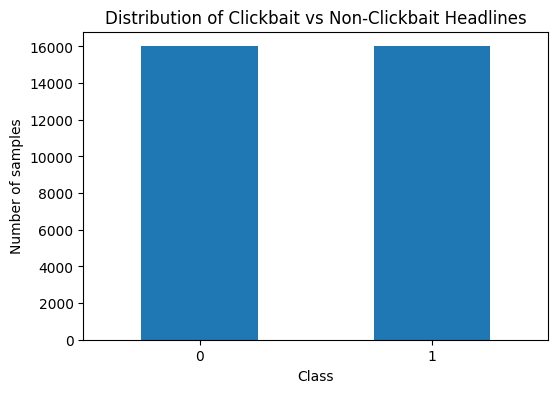

In [10]:
plt.figure(figsize=(6,4))

class_counts.plot(kind="bar")

plt.title("Distribution of Clickbait vs Non-Clickbait Headlines")
plt.xlabel("Class")
plt.ylabel("Number of samples")

plt.xticks(rotation=0)

plt.show()

Rezultati pokazuju raspodelu clickbait i non-clickbait naslova u skupu podataka. 
Relativno uravnotežena raspodela klasa je poželjna jer omogućava modelu da uči obrasce obe klase bez značajne pristrasnosti.

## 2.1 Analiza dužine naslova

In [11]:
# dužina u karakterima
df["char_length"] = df["headline"].str.len()

# dužina u tokenima (reči)
df["token_length"] = df["headline"].str.split().str.len()

df[["char_length", "token_length"]].describe()

,char_length,token_length
count,32000.000000,32000.000000
mean,53.797063,9.065156
std,14.771455,2.603603
min,6.000000,1.000000
25%,44.000000,7.000000
50%,52.000000,9.000000
75%,63.000000,11.000000
max,135.000000,26.000000


- Kao što možemo videti, prosečna dužina naslova iznosi oko **54 karaktera** i oko **9 tokena (reči)**
- Minimalna dužina je 1 token dok je maksimalna **26 tokena**
- Većina naslova (između 25% i 75% percentila) nalazi se u rasponu od **7 do 11 tokena**

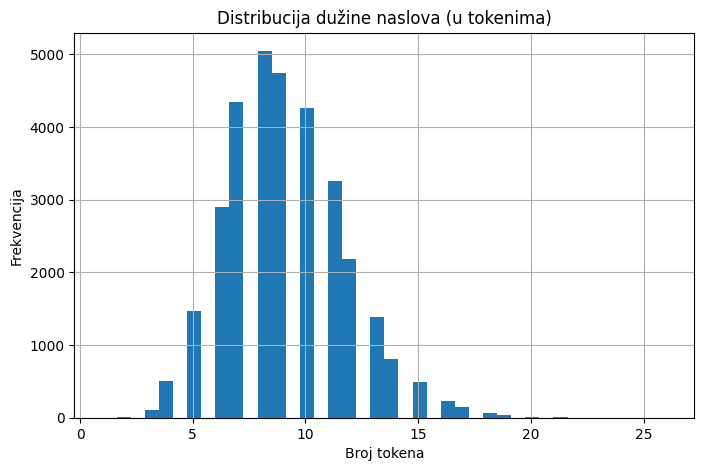

In [12]:
plt.figure(figsize=(8,5))
df["token_length"].hist(bins=40)
plt.title("Distribucija dužine naslova (u tokenima)")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.show()

- Histogram prikazuje da je distribucija dužine naslova približno unimodalna, sa najvećom frekvencijom u opsegu od 7 do 10 tokena.
- Uočava se blaga desna simetrija, što znači da postoji manji broj dužih naslova, dok je većina naslova oko prosečne vrednosti.
- Ekstremno kratki naslovi (1-3) tokena javljaju se retko, dok naslovi duži od 20 tokena predstavljaju mali procenat ukupnog skupa.

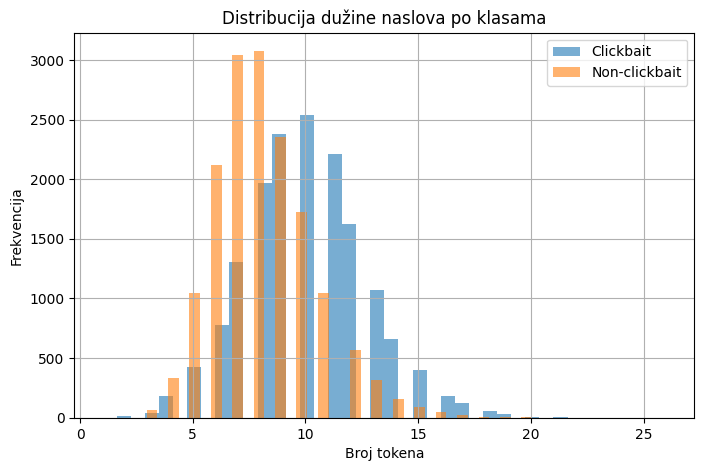

In [13]:
plt.figure(figsize=(8,5))

df[df["clickbait"] == 1]["token_length"].hist(
    bins=40, alpha=0.6, label="Clickbait"
)

df[df["clickbait"] == 0]["token_length"].hist(
    bins=40, alpha=0.6, label="Non-clickbait"
)

plt.legend()
plt.title("Distribucija dužine naslova po klasama")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.show()

Ovaj plot pokazuje jasnu razliku u dužini između clickbait i non-clickbait naslova.
- Clickbait naslovi imaju tendenciju da budu nešto duži od non-clickbait, sa većom frekvencijom u opsegu od 8 do 12 tokena
- Non-clickbait naslovi su najfrekventniji za vrednosti od 5 do 9 tokena
- Duži naslovi gotovo u potpunosti pripadaju clickbait naslovima

=> Ovo ukazuje da dužina naslova može predstavljati *informativnu karakteristiku* za klasifikaciju.

**Preciznija analiza:**

In [14]:
df.groupby("clickbait")["token_length"].describe()

,count,mean,std,min,25%,50%,75%,max
clickbait,,,,,,,,
0,16001.0,8.188613,2.224814,2.0,7.0,8.0,9.0,21.0
1,15999.0,9.941809,2.659194,1.0,8.0,10.0,12.0,26.0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6076\2841562527.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


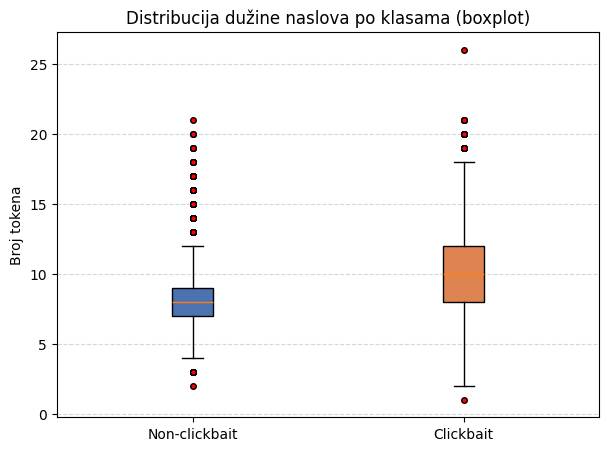

In [15]:
clickbait_lengths = df[df["clickbait"] == 1]["token_length"]
non_clickbait_lengths = df[df["clickbait"] == 0]["token_length"]

plt.figure(figsize=(7,5))

box = plt.boxplot(
    [non_clickbait_lengths, clickbait_lengths],
    labels=["Non-clickbait", "Clickbait"],
    patch_artist=True,
    showfliers=True
)

# boje kutija
colors = ["#4C72B0", "#DD8452"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# crvene tačkice za outlier-e
for flier in box["fliers"]:
    flier.set(marker='o', markerfacecolor='red', markersize=4, linestyle='none')

plt.title("Distribucija dužine naslova po klasama (boxplot)")
plt.ylabel("Broj tokena")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Detaljnija analiza:

- Prosečna dužina non-clickbait naslova iznosi približno **8.19 tokena**, dok clickbait naslovi imaju višu prosečnu dužinu od oko **9.94 tokena**.
- Medijana non-clickbait naslova iznosi **8 tokena**, dok je medijana clickbait naslova **10 tokena**.
- Interkvartilni opseg (IQR) kod non-clickbait naslova kreće se između **7 i 9 tokena**, dok je kod clickbait naslova širi, u rasponu od **8 do 12 tokena**.

Clickbait naslovi pokazuju veću varijabilnost i veći raspon maksimalnih vrednosti (do 26 tokena), 
što ukazuje na to da su u proseku duži i strukturalno kompleksniji.

Ovi rezultati sugerišu da dužina naslova predstavlja potencijalno informativnu karakteristiku za klasifikaciju, kao što smo rekli
jer postoji konzistentna razlika između dve klase.

Napomena: Kolone `char_length` i `token_length` kreirane su isključivo u svrhu eksplorativne analize i neće biti korišćene kao ulazne karakteristike u modelu.

---------------------------------------

## 2.2 Analiza vokabulara

U ovoj sekciji analiziramo vokabular skupa podataka što podrazumeva: broj jedinstvenih reči (vocabulary size), najčešće reči, udeo retkih reči

(ovo je jako bitno jer utiče ba sparsity TF-IDF matrice..)

In [16]:
def tokenize_for_eda(text: str):
    """
    Minimalna tokenizacija za EDA:
    - lowercase
    - zadržava reči i apostrofe (npr. "don't")
    - izbacuje interpunkciju
    """
    text = str(text).lower()
    return re.findall(r"[a-z']+", text)

# primer tokenizacije na prvih 3 naslova
for i in range(3):
    print(df.loc[i, "headline"])
    print(tokenize_for_eda(df.loc[i, "headline"]))
    print("----")

Should I Get Bings
['should', 'i', 'get', 'bings']
----
Which TV Female Friend Group Do You Belong In
['which', 'tv', 'female', 'friend', 'group', 'do', 'you', 'belong', 'in']
----
The New "Star Wars: The Force Awakens" Trailer Is Here To Give You Chills
['the', 'new', 'star', 'wars', 'the', 'force', 'awakens', 'trailer', 'is', 'here', 'to', 'give', 'you', 'chills']
----


**Napomena:** Ova tokenizacija se koristi samo za EDA i merenje statistika vokabulara.  
U modelu ćemo koristiti `TfidfVectorizer`, koji ima sopstvenu tokenizaciju i parametre.

In [17]:
all_tokens = []
for t in df["headline"]:
    all_tokens.extend(tokenize_for_eda(t))

token_count_total = len(all_tokens)
vocab = set(all_tokens)
vocab_size = len(vocab)

print("Ukupan broj tokena u korpusu:", token_count_total)
print("Veličina vokabulara (unikatne reči):", vocab_size)
print("Prosečan broj tokena po naslovu:", token_count_total / len(df))

Ukupan broj tokena u korpusu: 283998
Veličina vokabulara (unikatne reči): 23627
Prosečan broj tokena po naslovu: 8.8749375


Ukupan broj tokena u korpusu iznosi **283,998**, dok veličina vokabulara (broj jedinstvenih reči) iznosi **23,627**.

Prosečan broj tokena po naslovu je približno **8.87**, što je u skladu sa prethodnom analizom dužine naslova.

Odnos između ukupnog broja tokena i veličine vokabulara ukazuje na relativno bogat i raznovrstan leksički fond.
Međutim, s obzirom na to da je broj instanci 32,000, vokabular od 23,627 jedinstvenih reči sugeriše potencijalno visoku dimenzionalnost
u TF-IDF reprezentaciji, što može dovesti do sparsity problema.

In [18]:
# Vocabulary size po klasama (clickbait vs non-clickbait)

def get_vocab(texts):
    tokens = []
    for t in texts:
        tokens.extend(tokenize_for_eda(t))
    return set(tokens)

vocab_all = get_vocab(df["headline"])
vocab_cb  = get_vocab(df[df["clickbait"] == 1]["headline"])
vocab_non = get_vocab(df[df["clickbait"] == 0]["headline"])

print("Vocabulary size (overall):", len(vocab_all))
print("Vocabulary size (clickbait=1):", len(vocab_cb))
print("Vocabulary size (non-clickbait=0):", len(vocab_non))

# (bonus) presek i unikatne reči po klasama
intersection = vocab_cb & vocab_non
only_cb = vocab_cb - vocab_non
only_non = vocab_non - vocab_cb

print("\nPresek vokabulara (zajedničke reči):", len(intersection))
print("Samo u clickbait:", len(only_cb))
print("Samo u non-clickbait:", len(only_non))

Vocabulary size (overall): 23627
Vocabulary size (clickbait=1): 11912
Vocabulary size (non-clickbait=0): 17263

Presek vokabulara (zajedničke reči): 5548
Samo u clickbait: 6364
Samo u non-clickbait: 11715


Ukupan broj jedinstvenih tokena u korpusu iznosi 23 627, što ukazuje na relativno bogat rečnik uprkos kratkoj formi tekstova (naslova).

Analiza po klasama pokazuje da non-clickbait naslovi imaju veći vokabular (17 263 jedinstvenih tokena) u odnosu na clickbait naslove (11 912 tokena). Ova razlika sugeriše da informativni naslovi koriste raznovrsniji i precizniji jezik, dok clickbait naslovi češće koriste ograničen skup ponavljajućih fraza i obrazaca.

Presek vokabulara između klasa iznosi 5 548 reči, što potvrđuje da značajan deo opšteg jezika dele obe klase. Međutim, 6 364 reči su specifične za clickbait, dok je čak 11 715 specifično za non-clickbait, što dodatno ukazuje na veću leksičku raznovrsnost informativnih naslova.

In [19]:
from typing import Counter


cnt = Counter(all_tokens)

top_n = 20
top_words = cnt.most_common(top_n)

top_df = pd.DataFrame(top_words, columns=["word", "freq"])
top_df

,word,freq
0,to,6674
1,in,6502
2,the,6413
3,of,5111
4,you,4859
5,a,4188
6,for,3174
7,and,2835
8,on,2783
9,your,2580


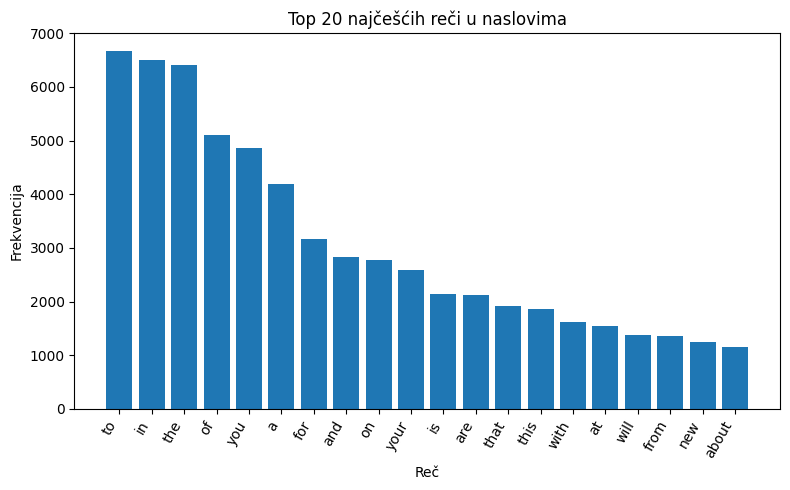

In [20]:
plt.figure(figsize=(8,5))
plt.bar(top_df["word"], top_df["freq"])
plt.title("Top 20 najčešćih reči u naslovima")
plt.xlabel("Reč")
plt.ylabel("Frekvencija")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Najčešće reči u korpusu su pretežno funkcionalne reči (npr. *to, in, the, of, and*), 
što je očekivano u engleskom jeziku.

Međutim, zanimljivo je prisustvo reči kao što su *you* i *your*, 
koje se često povezuju sa clickbait stilom (direktno obraćanje čitaocu).

Ova analiza ukazuje da *potpuno automatsko uklanjanje stop-reči možda nije optimalna strategija*,
jer neke od čestih funkcionalnih reči mogu nositi signal relevantan za detekciju clickbait sadržaja.

In [21]:
freqs = np.array(list(cnt.values()))

hapax_count = np.sum(freqs == 1)
hapax_share_vocab = hapax_count / len(freqs)

print("Broj hapax reči (freq=1):", hapax_count)
print("Udeo hapax reči u vokabularu:", hapax_share_vocab)

# koliko reči se pojavljuje manje od 2/3/5 puta
for k in [2, 3, 5]:
    share = np.mean(freqs < k)
    print(f"Udeo reči sa frekvencijom < {k}: {share:.3f}")

Broj hapax reči (freq=1): 10745
Udeo hapax reči u vokabularu: 0.4547763152325729
Udeo reči sa frekvencijom < 2: 0.455
Udeo reči sa frekvencijom < 3: 0.603
Udeo reči sa frekvencijom < 5: 0.730


Analiza frekvencija pokazuje sledeće:

- Broj hapax reči (reči koje se pojavljuju samo jednom) iznosi **10,745**, 
  što predstavlja približno **45.5% ukupnog vokabulara**.
- Čak **60.3% reči** pojavljuje se manje od 3 puta,
- dok se **73.0% reči** pojavljuje manje od 5 puta.

Ovi rezultati ukazuju na veoma visok udeo retkih tokena u korpusu.

Veliki procenat retkih reči može dovesti do:
- povećane dimenzionalnosti TF-IDF matrice,
- veće sparsity reprezentacije,
- smanjene generalizacije modela.

Zbog toga postoji jasna motivacija za eksperimentalno testiranje parametra `min_df`,kojim se uklanjaju tokeni koji se pojavljuju u premalom broju dokumenata.

In [22]:
# Najčešće reči u clickbait naslovima
top_cb = (
    df[df["clickbait"] == 1]["headline"]
    .str.split(expand=True)
    .stack()
    .value_counts()
    .reset_index()
)

top_cb.columns = ["word", "freq_clickbait"]


# Najčešće reči u non-clickbait naslovima
top_non = (
    df[df["clickbait"] == 0]["headline"]
    .str.split(expand=True)
    .stack()
    .value_counts()
    .reset_index()
)

top_non.columns = ["word", "freq_non_clickbait"]

In [23]:
# Spajanje tabela po reči (clickbait vs non-clickbait)

top_compare = pd.merge(
    top_cb,
    top_non,
    on="word",
    how="outer"
).fillna(0)

# pretvori frekvencije u int (da ne budu float zbog fillna)
top_compare["freq_clickbait"] = top_compare["freq_clickbait"].astype(int) #koliko puta se rec pojavljuje u clickbait naslovima
top_compare["freq_non_clickbait"] = top_compare["freq_non_clickbait"].astype(int) #koliko se puta pojavljuje u nonclikbait

# razlika frekvencija
top_compare["diff_clickbait_minus_non"] = ( 
    top_compare["freq_clickbait"] - top_compare["freq_non_clickbait"]
)

#apsolutna razlika
top_compare["abs_diff"] = top_compare["diff_clickbait_minus_non"].abs()

top_compare = top_compare.sort_values("abs_diff", ascending=False)

# prikaz top 20 najrazličitijih reči
top_compare.head(20)

,word,freq_clickbait,freq_non_clickbait,diff_clickbait_minus_non,abs_diff
27067,You,4805,19,4786,4786
24477,The,4723,171,4552,4552
31014,in,6,4354,-4348,4348
34946,to,7,3394,-3387,3387
24735,To,3231,23,3208,3208
32272,of,12,2662,-2650,2650
27088,Your,2536,37,2499,2499
17774,Of,2422,4,2418,2418
2542,A,2600,234,2366,2366
3619,Are,1938,127,1811,1811


Poređenjem najčešćih reči u clickbait i non-clickbait naslovima mogu se uočiti jasne stilističke razlike.

Kod clickbait naslova među najfrekventnijim rečima pojavljuju se:
- *you*
- *your*
- *this*
- *that*
- *will*

Ove reči ukazuju na direktno obraćanje čitaocu i naglašavanje budućih ili emocionalnih događaja,
što je tipična karakteristika clickbait stila.

Sa druge strane, non-clickbait naslovi češće sadrže reči kao što su:
- *in*
- *at*
- *new*
- *after*
- *with*

Ove reči su karakteristične za informativne i neutralne novinarske konstrukcije.

Ova razlika potvrđuje da clickbait i non-clickbait naslovi koriste različite jezičke obrasce, što sugeriše da model može naučiti razlike ne samo na osnovu dužine,
već i na osnovu leksičkih karakteristika teksta.

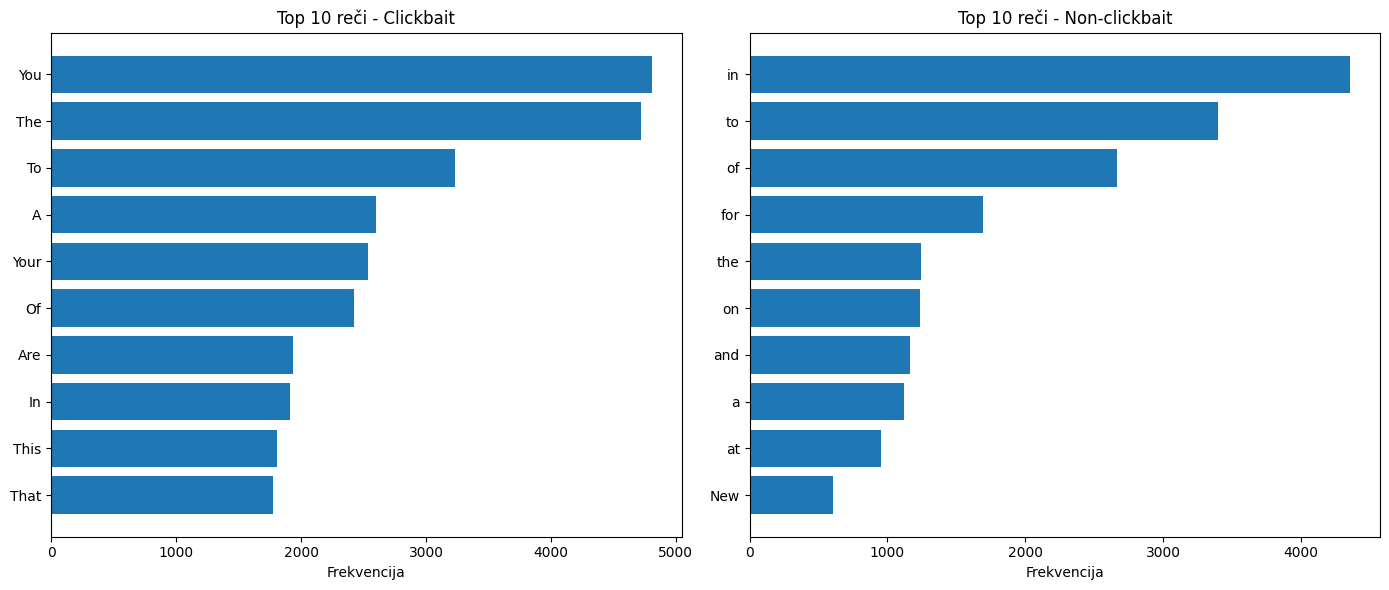

In [24]:
import matplotlib.pyplot as plt

# uzimamo top 10 po klasama
top_cb_10 = top_cb.head(10)
top_non_10 = top_non.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clickbait graf
axes[0].barh(top_cb_10["word"], top_cb_10["freq_clickbait"])
axes[0].invert_yaxis()
axes[0].set_title("Top 10 reči - Clickbait")
axes[0].set_xlabel("Frekvencija")

# Non-clickbait graf
axes[1].barh(top_non_10["word"], top_non_10["freq_non_clickbait"])
axes[1].invert_yaxis()
axes[1].set_title("Top 10 reči - Non-clickbait")
axes[1].set_xlabel("Frekvencija")

plt.tight_layout()
plt.show()

Vizuelna ilustracija leksičkih razlika između klasa

### 2.2.1 WordCloud analiza

WordCloud predstavlja vizuelnu tehniku za prikaz najčešćih reči u tekstualnom korpusu. 
Veličina svake reči proporcionalna je njenoj učestalosti u skupu podataka. 
Na ovaj način možemo intuitivno uočiti koje reči dominiraju u clickbait i non-clickbait naslovima.

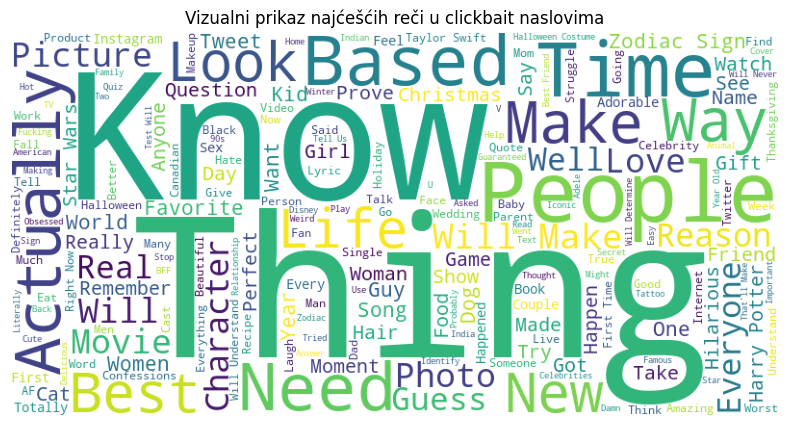

In [25]:
from wordcloud import WordCloud
clickbait_text = " ".join(df[df["clickbait"] == 1]["headline"])

wordcloud_clickbait = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(clickbait_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_clickbait)
plt.axis("off")
plt.title("Vizualni prikaz najćešćih reči u clickbait naslovima")

plt.show()

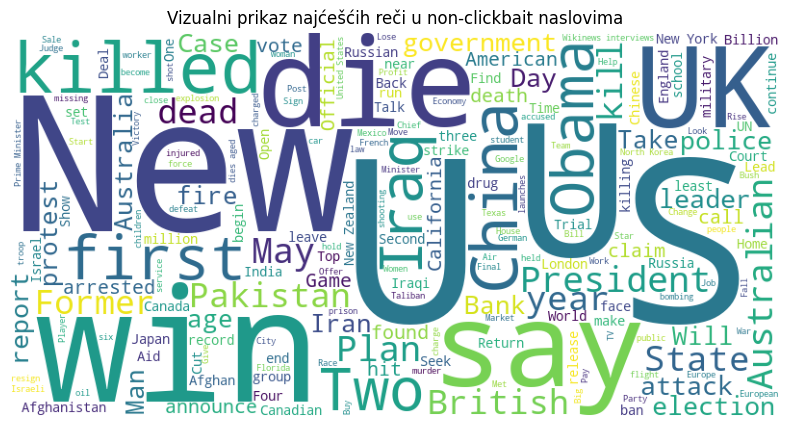

In [26]:
non_clickbait_text = " ".join(df[df["clickbait"] == 0]["headline"])

wordcloud_non = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(non_clickbait_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_non)
plt.axis("off")
plt.title("Vizualni prikaz najćešćih reči u non-clickbait naslovima")

plt.show()

Vizuelna analiza pokazuje razlike u vokabularu između clickbait i standardnih naslova. 
Clickbait naslovi češće sadrže emocionalno obojene ili senzacionalističke izraze, dok su 
non-clickbait naslovi informativniji i neutralniji.

## 2.3 Stil i signal

U ovom podpoglavlju posmatramo koliko naslova sadrži znakove interpunkcije, brojeve, reči napisane velikim slovima.

1. Ukupna zastupljenost stilskih indikatora:


In [27]:
# indikator za !
df["has_exclamation"] = df["headline"].str.contains("!", regex=False)

# indikator za ?
df["has_question"] = df["headline"].str.contains("?", regex=False)

# indikator za broj
df["has_number"] = df["headline"].str.contains(r"\d", regex=True)

# indikator za ALL CAPS reči (min 3 slova)
df["has_allcaps"] = df["headline"].str.contains(r"\b[A-Z]{3,}\b", regex=True)

# indikator za dvostruke navodnike "
df["has_double_quotes"] = df["headline"].str.contains('"', regex=False)

# indikator za jednostruke navodnike '
df["has_single_quotes"] = df["headline"].str.contains("'", regex=False)

# indikator za okrugle zagrade ()
df["has_parentheses"] = df["headline"].str.contains(r"[()]", regex=True)

# prosečne vrednosti (učešće u datasetu)
df[[
    "has_exclamation",
    "has_question",
    "has_number",
    "has_allcaps",
    "has_double_quotes",
    "has_single_quotes",
    "has_parentheses"
]].mean()

has_exclamation      0.001187
has_question         0.005000
has_number           0.313688
has_allcaps          0.051687
has_double_quotes    0.077281
has_single_quotes    0.151812
has_parentheses      0.002812
dtype: float64

Analiza pokazuje:
- Uzvičnik (!) prisutan je u približno **0.12%** naslova.
- Upitnik (?) pojavljuje se u oko **0.5%** naslova.
- Brojevi su prisutni u čak **31.4%** naslova.
- ALL CAPS reči javljaju se u oko **5.2%** naslova.

Najzastupljeniji indikator su brojevi, što je u skladu sa tipičnim clickbait obrascem
(npr. “7 things…”, “10 reasons…”).

In [28]:
df.groupby("clickbait")[[
    "has_exclamation",
    "has_question",
    "has_number",
    "has_allcaps",
    "has_double_quotes",
    "has_single_quotes",
    "has_parentheses"
]].mean() * 100 #za procente

,has_exclamation,has_question,has_number,has_allcaps,has_double_quotes,has_single_quotes,has_parentheses
clickbait,,,,,,,
0,0.049997,0.731204,18.630086,6.787076,1.187426,7.168302,0.199988
1,0.187512,0.268767,44.109007,3.550222,14.269642,23.195200,0.362523


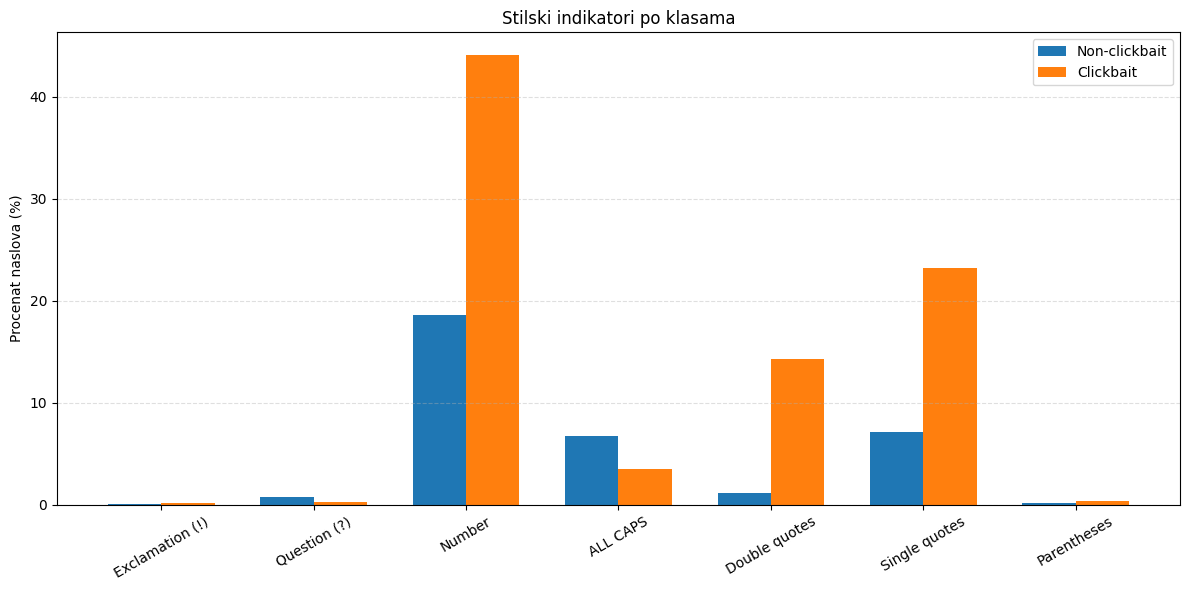

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# izračunavanje srednjih vrednosti
style_means = df.groupby("clickbait")[[
    "has_exclamation",
    "has_question",
    "has_number",
    "has_allcaps",
    "has_double_quotes",
    "has_single_quotes",
    "has_parentheses"
]].mean()

# u procente
style_means_percent = style_means * 100

# etikete (mora isti redosled kao kolone)
labels = [
    "Exclamation (!)",
    "Question (?)",
    "Number",
    "ALL CAPS",
    "Double quotes",
    "Single quotes",
    "Parentheses"
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x - width/2, style_means_percent.loc[0].values, width, label="Non-clickbait")
ax.bar(x + width/2, style_means_percent.loc[1].values, width, label="Clickbait")

ax.set_ylabel("Procenat naslova (%)")
ax.set_title("Stilski indikatori po klasama")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Poređenje stilskih indikatora po klasama otkriva jasne i konzistentne razlike između clickbait i non-clickbait naslova.

Najizraženija razlika uočena je kod upotrebe brojeva: oni su prisutni u približno 44.1% clickbait naslova, dok se u non-clickbait naslovima pojavljuju u svega 18.6% slučajeva. Ovaj rezultat potvrđuje da numeričke konstrukcije (tzv. listicle obrasci) predstavljaju dominantnu stilsku karakteristiku clickbait sadržaja.

Pored toga, značajna razlika uočena je i kod upotrebe navodnika. Double quotes se pojavljuju u oko 14.3% clickbait naslova, naspram samo 1.2% u non-clickbait klasi, dok su single quotes prisutni u oko 23.2% clickbait naslova u poređenju sa 7.2% u non-clickbait grupi. Ovi rezultati ukazuju da clickbait naslovi češće koriste narativni ili senzacionalistički stil izražavanja.

Sa druge strane, ALL CAPS reči su češće zastupljene u non-clickbait naslovima (6.8%) nego u clickbait naslovima (3.6%), što sugeriše da kapitalizacija nije dominantan clickbait signal u ovom skupu podataka. Upitnici, uzvičnici i zagrade pokazuju nisku učestalost u obe klase, te ne predstavljaju snažan diskriminativni faktor.

Ukupno posmatrano, stilistički obrasci sa najvećom diskriminativnom vrednošću u ovom korpusu su numeričke konstrukcije i upotreba navodnika, dok ostali analizirani indikatori imaju ograničen doprinos razlikovanju klasa.

## 2.4 Lexical Diversity (TTR)

U ovoj sekciji merimo leksičku raznovrsnost (TTR - Type-Token Ratio), ona predstavlja odnos između broja jedinstvenih reči i ukupnog broja tokena.

Ova metrika pruža uvid u raznovrsnost jezika, potencijalnu repetetivnost stilskih obrazaca, razlike u leksičkoj kompleksnosti između klasa.

In [30]:
def compute_ttr(texts):
    tokens = []
    for t in texts:
        tokens.extend(tokenize_for_eda(t))
    return len(set(tokens)) / len(tokens)

ttr_overall = compute_ttr(df["headline"])
ttr_cb = compute_ttr(df[df["clickbait"] == 1]["headline"])
ttr_non = compute_ttr(df[df["clickbait"] == 0]["headline"])

print("TTR (ukupno):", ttr_overall)
print("TTR (clickbait):", ttr_cb)
print("TTR (non-clickbait):", ttr_non)

TTR (ukupno): 0.08319424784681582
TTR (clickbait): 0.07787758731154958
TTR (non-clickbait): 0.1317384004884005


*Budući da su klase približno izjednačene po broju dokumenata, poređenje TTR vrednosti je metodološki opravdano.*

Ukupna vrednost TTR u korpusu iznosi približno **0.083**, što ukazuje na relativno nisku leksičku raznovrsnost, što je očekivano za kratke tekstualne forme poput naslova.

Međutim, razlika između klasa je izražena:

- Clickbait naslovi imaju nižu TTR vrednost (**0.078**), što sugeriše veću repetitivnost i upotrebu šablonskih fraza.
- Non-clickbait naslovi pokazuju značajno višu TTR vrednost (**0.131**), što ukazuje na raznovrsniji i informativniji vokabular.

Ovi rezultati potvrđuju hipotezu da clickbait stil karakteriše veća upotreba ponavljajućih obrazaca i ograničenog skupa reči, dok non-clickbait naslovi pokazuju veću leksičku raznovrsnost.

## 2.5 Analiza šuma u tekstualnom korpusu

Kvalitet tekstualnih podataka u velikoj meri zavisi od prisustva tehničkog šuma, koji može negativno uticati na proces tokenizacije, vektorizacije i performanse modela mašinskog učenja. 
U okviru ove analize izvršeba je detekcija sledećih potencijalnih izvora šumova:
- HTML tagovi
- Emoji simboliu (unicode opseg)
- Višestruki uzvičnici i upitnici
- Specijalni simboli koji odstupaju od staandardne alfanumeričke strukture

In [31]:
# 1. HTML tagovi
df["has_html"] = df["headline"].str.contains(r"<.*?>", regex=True)

# 2. Pravi emoji (Unicode opseg)
df["has_emoji"] = df["headline"].str.contains(
    r"[\U00010000-\U0010ffff]", 
    regex=True
)

# 3. Višestruki uzvičnici
df["multiple_exclamation"] = df["headline"].str.contains(r"!{2,}", regex=True)

# 4. Višestruki upitnici
df["multiple_question"] = df["headline"].str.contains(r"\?{2,}", regex=True)

# 5. Nealfanumerički simboli (bez standardne interpunkcije)
df["has_special_symbols"] = df["headline"].str.contains(
    r"[^a-zA-Z0-9\s\.\,\!\?\-\'\"]",
    regex=True
)

# Procenat pojavljivanja po klasama
noise_stats = df.groupby("clickbait")[[
    "has_html",
    "has_emoji",
    "multiple_exclamation",
    "multiple_question",
    "has_special_symbols"
]].mean() * 100

noise_stats

,has_html,has_emoji,multiple_exclamation,multiple_question,has_special_symbols
clickbait,,,,,
0,0.0,0.0,0.000000,0.0,9.430661
1,0.0,0.0,0.012501,0.0,3.843990


Analiza tehničkog šuma pokazuje da dataset ne sadrži HTML oznake niti emoji simbole, što ukazuje na visok inicijalni kvalitet podataka. Prisustvo višestrukih znakova interpunkcije je zanemarljivo, čak i kod clickbait naslova.

Interesantno je da non-clickbait naslovi imaju veći procenat specijalnih simbola (9.43%) u odnosu na clickbait naslove (3.84%). Ovo može biti posledica češće upotrebe crtica, zagrada ili tehničkih termina u informativnim naslovima, dok clickbait naslovi teže jednostavnijoj i direktnijoj formi izražavanja.

Ovi rezultati potvrđuju da dataset ne sadrži značajan tehnički šum koji bi degradirao performanse modela, te da eventualne razlike između klasa proizilaze iz stilističkih, a ne tehničkih karakteristika.

------------------------------

# 3. Modeliranje: Baseline model

Nakon analize kvaliteta i stilskih karakteristika teksta, prelazimo na fazu modeliranja. 
Cilj baseline modela je da se uspostavi referentna tacka performansi bez napredne preobrade teksta.

Baseline model koristi:
- TF-IDF reprezentaciju teksta
- Logistic Regression klasifikator
- Minimalnu obradu

Ovaj pristup omogućava proceni koliko sam model može da detektuje obrasce bez dodatnih poboljšsanja.

## 3.1 Podela podataka (stratified split)

Podatke delimo na trening i test skupu (80/20).
Koristimo *stratifikovanu* podelu kako bi distribucija klasa ostala proporcionalna u oba skupa -> time se obezbeđuje reprezentativna evaluacija modela

In [32]:
X = df["headline"]
y = df["clickbait"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Distribucija klasa u trening skupu:")
print(y_train.value_counts(normalize=True))

print("\nDistribucija klasa u test skupu:")
print(y_test.value_counts(normalize=True))

Distribucija klasa u trening skupu:
clickbait
0    0.500039
1    0.499961
Name: proportion, dtype: float64

Distribucija klasa u test skupu:
clickbait
1    0.5
0    0.5
Name: proportion, dtype: float64


## 3.2 Baseline model: TF-IDF + Logistic Regression

Baseline model koristi TF-IDF reprezentaciju bez:
- uklanjanja stop reči
- n-grama
- dodatne normalizacije
- filtriranja retkih ili čestih tokena

Na ovaj način dobijamo referentne performanse pre primene naprednih tehnika preobrade.

In [33]:
#baseline model
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True)),
    ("clf", LogisticRegression(max_iter=2000))
])
#treniramo trening skup
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

## 3.3 Evaluacija baseline modela

Model se evaluira na test skupu koristeći sledeće metrike:
- Accuracy (tacnost)
- Precision
- Recall
- F1-score

F1-score je posebno značajan kod binarne tekstualne klasifikacije jer balansira preciznost i odziv

In [34]:
report_dict = classification_report(
    y_test,
    y_pred_baseline,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df = report_df.loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]

report_df.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

report_df = report_df.round(4)

styled_report = (
    report_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Baseline Model – Classification Report")
    .set_properties(**{
        'font-size': '18px',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "22px"),
                   ("font-weight", "bold"),
                   ("text-align", "center"),
                   ("margin-bottom", "15px")]},
        {"selector": "th",
         "props": [("font-size", "18px"),
                   ("text-align", "center")]},
    ])
)

styled_report

,precision,recall,f1-score,support
Non-Clickbait,0.9581,0.9781,0.9680,3200
Clickbait,0.9777,0.9572,0.9673,3200
Accuracy,0.9677,0.9677,0.9677,1
Macro Avg,0.9679,0.9677,0.9677,6400
Weighted Avg,0.9679,0.9677,0.9677,6400


Baseline model ostvaruje ukupnu **tačnost (accuracy) od 96.77%**, što ukazuje na veoma visoke početne performanse u zadatku detekcije clickbait naslova.

S obzirom na to da je skup podataka balansiran (3200 primera po klasi), accuracy predstavlja pouzdanu metriku i nije rezultat neravnoteže klasa.

**Klasa: Non-Clickbait**

- **Precision:** 0.9581  
- **Recall:** 0.9781  
- **F1-score:** 0.9680  

Model pokazuje izuzetno dobre performanse u prepoznavanju non-clickbait naslova.  
Visoka vrednost recall (97.81%) znači da model retko propušta stvarne non-clickbait primere.

Precision od 95.81% ukazuje da mali procenat clickbait naslova biva pogrešno klasifikovan kao non-clickbait.

Ovi rezultati potvrđuju da model vrlo uspešno identifikuje neutralne i informativne naslove.

**Klasa: Clickbait**

- **Precision:** 0.9777  
- **Recall:** 0.9572  
- **F1-score:** 0.9673  

Model je veoma precizan prilikom predviđanja clickbait sadržaja (97.77%), što znači da su predikcije ove klase u velikoj meri tačne.

Međutim, nešto niža vrednost recall (95.72%) pokazuje da model propušta određeni broj clickbait primera.

To ukazuje na to da baseline model može imati poteškoća u prepoznavanju suptilnijih ili semantički kompleksnijih clickbait obrazaca.


**Uravnoteženost modela**

Vrednosti **Macro Average F1-score (0.9677)** i **Weighted Average F1-score (0.9677)** su gotovo identične, što potvrđuje da model ne favorizuje nijednu klasu i da su performanse ravnomerno raspoređene.

**Zaključak**

Rezultati pokazuju da baseline model ostvaruje veoma visoke i stabilne performanse.  
Iako su metrike već na visokom nivou, dalja unapređenja mogu biti usmerena na povećanje recall vrednosti za clickbait klasu kako bi se smanjio broj propuštenih primera.

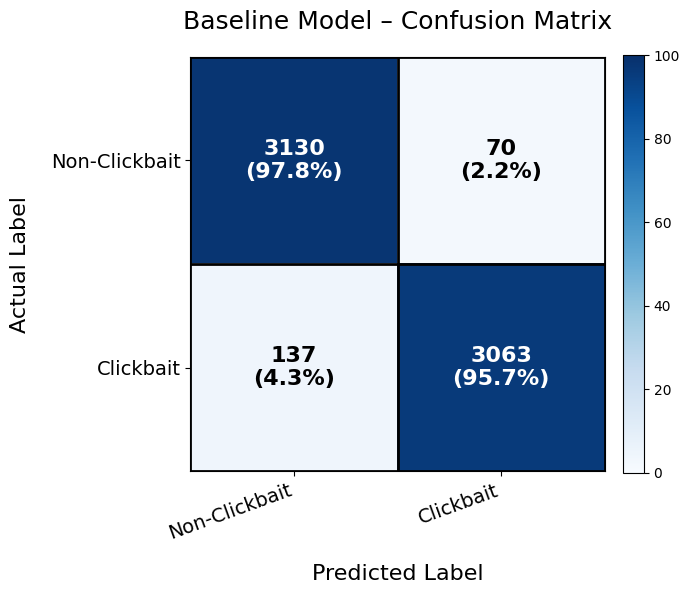

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Kreiramo matricu
cm = confusion_matrix(y_test, y_pred_baseline)

# Računamo procente po redu
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

fig, ax = plt.subplots(figsize=(7, 7))

# JAČI colormap
im = ax.imshow(cm_percent, cmap="Blues", vmin=0, vmax=100)

# Obeležavanje osa
classes = ["Non-Clickbait", "Clickbait"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=14)
ax.set_yticklabels(classes, fontsize=14)

ax.set_xlabel("Predicted Label", fontsize=16, labelpad=15)
ax.set_ylabel("Actual Label", fontsize=16, labelpad=15)

# Rotacija x labela
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# Upis vrednosti unutar kvadrata
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm_percent[i, j] > 50 else "black"
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            color=text_color,
            fontsize=16,
            fontweight="bold"
        )

# Pravimo kvadrate savršeno jednake
ax.set_aspect("equal")

# Grid linije da izgleda kao prava matrica
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Naslov
plt.title("Baseline Model – Confusion Matrix", fontsize=18, pad=20)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

 ## 3.4 Interpretacija modela – najvažnije reči

Koeficijenti logističke regresije omogućavaju interpretaciju modela. 
Pozitivni koeficijenti ukazuju na reči koje su karakteristične za clickbait naslove, 
dok negativni koeficijenti ukazuju na reči tipične za non-clickbait naslove.

Analiza ovih reči omogućava uvid u lingvističke obrasce koje model koristi za klasifikaciju.

In [36]:
vectorizer = baseline_model.named_steps["tfidf"]
model = baseline_model.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

In [37]:
top_clickbait = np.argsort(coefficients)[-20:]

print("Top words indicating CLICKBAIT:\n")

for i in reversed(top_clickbait):
    print(feature_names[i], coefficients[i])

Top words indicating CLICKBAIT:

you 12.519105422938566
this 9.042072776233189
your 8.349354713340826
the 6.322480147977565
that 5.981446273298825
these 5.925133082276824
people 5.423319803857711
17 5.413816280275033
are 5.273995416524507
what 5.266297897986185
2015 5.206715272013069
things 5.136277648590377
how 5.134157505323017
here 5.068652126727773
21 5.010845550206033
we 4.972469925260536
who 4.957898158872104
her 4.8648238148236
19 4.493548120819098
everyone 4.352671521948558


In [38]:
top_non = np.argsort(coefficients)[:20]

print("Top words indicating NON-CLICKBAIT:\n")

for i in top_non:
    print(feature_names[i], coefficients[i])

Top words indicating NON-CLICKBAIT:

in -4.131920937794967
obama -3.3651194802812943
wins -3.2321548081548555
dies -3.160361421989014
uk -3.1188185810000877
says -3.0428466414714737
australian -2.7199831821510614
china -2.462884508075658
kills -2.3963643810923925
may -2.3112053239198995
court -2.3041260835004005
killed -2.2693210863406867
mets -2.2477511008221023
police -2.241382691908118
iraq -2.233696345297738
wikinews -2.1788269661913153
at -2.1570166912244697
president -2.1317724172387096
knicks -2.0562585558436313
dead -2.014817948607436


Zaključak interpretacije

Rezultati analize pokazuju da model uspešno prepoznaje lingvističke obrasce karakteristične za clickbait sadržaj. Clickbait naslovi često koriste personalizovan i emocionalno obojen jezik, dok non-clickbait naslovi sadrže više informativnih i konkretnih termina. 

Ova interpretacija potvrđuje da model donosi odluke na osnovu relevantnih jezičkih karakteristika teksta, što dodatno doprinosi njegovoj interpretabilnosti i pouzdanosti.

Važno je napomenuti da se ova analiza razlikuje od prethodne eksploratorne analize podataka (EDA). 
U ranijoj fazi analizirane su najčešće reči u datasetu na osnovu frekvencije pojavljivanja. 
U ovoj fazi analiziraju se koeficijenti modela logističke regresije, koji predstavljaju stvarni 
doprinos pojedinačnih reči u procesu klasifikacije. 

Zbog toga su u ovoj analizi identifikovane reči koje model smatra najinformativnijim za razlikovanje 
clickbait i non-clickbait naslova, a ne nužno reči koje se najčešće pojavljuju u datasetu.

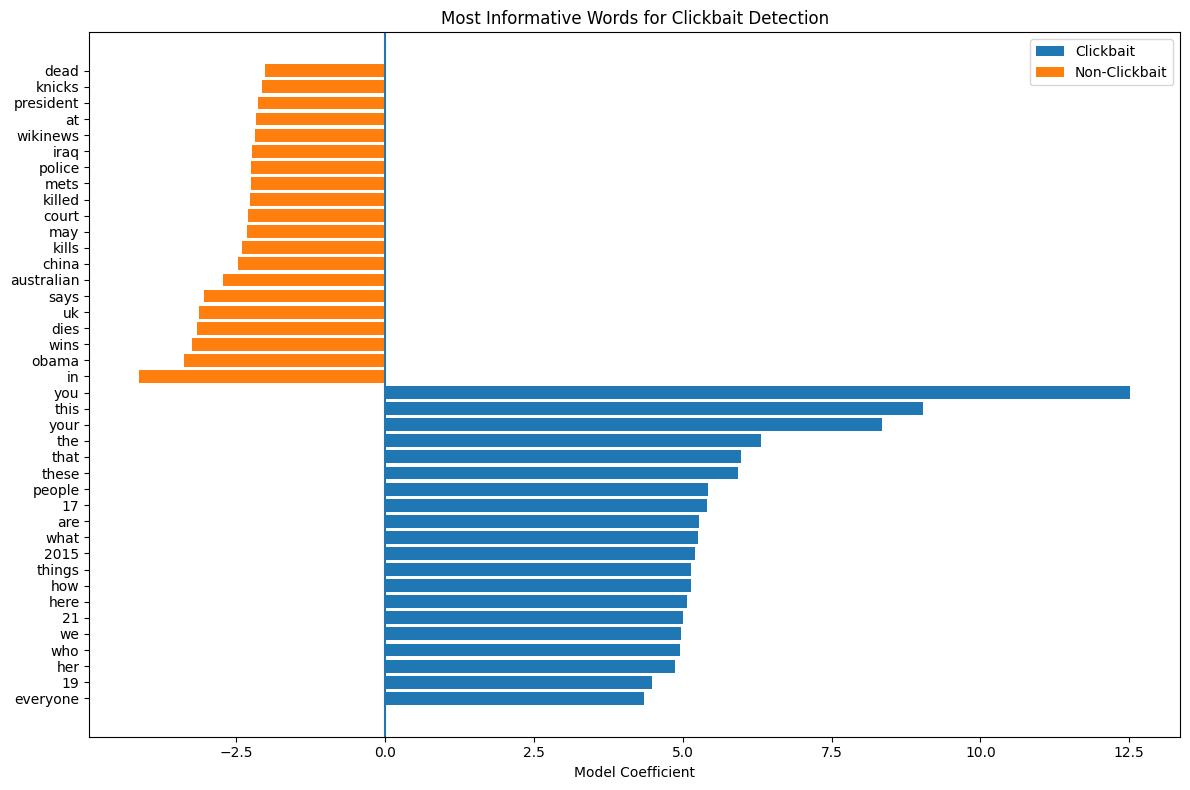

In [39]:
# uzimamo komponente pipeline-a
vectorizer = baseline_model.named_steps["tfidf"]
model = baseline_model.named_steps["clf"]

# feature names i koeficijenti
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# top clickbait (pozitivni koeficijenti)
top_cb_idx = np.argsort(coefficients)[-20:]
top_cb_words = feature_names[top_cb_idx]
top_cb_scores = coefficients[top_cb_idx]

# top non-clickbait (negativni koeficijenti)
top_non_idx = np.argsort(coefficients)[:20]
top_non_words = feature_names[top_non_idx]
top_non_scores = coefficients[top_non_idx]

# DataFrame za lakše crtanje
cb_df = pd.DataFrame({
    "word": top_cb_words,
    "score": top_cb_scores
}).sort_values("score")

non_df = pd.DataFrame({
    "word": top_non_words,
    "score": top_non_scores
}).sort_values("score")

# vizualizacija
plt.figure(figsize=(12,8))

plt.barh(cb_df["word"], cb_df["score"], label="Clickbait")
plt.barh(non_df["word"], non_df["score"], label="Non-Clickbait")

plt.axvline(0)
plt.xlabel("Model Coefficient")
plt.title("Most Informative Words for Clickbait Detection")

plt.legend()

plt.tight_layout()
plt.show()

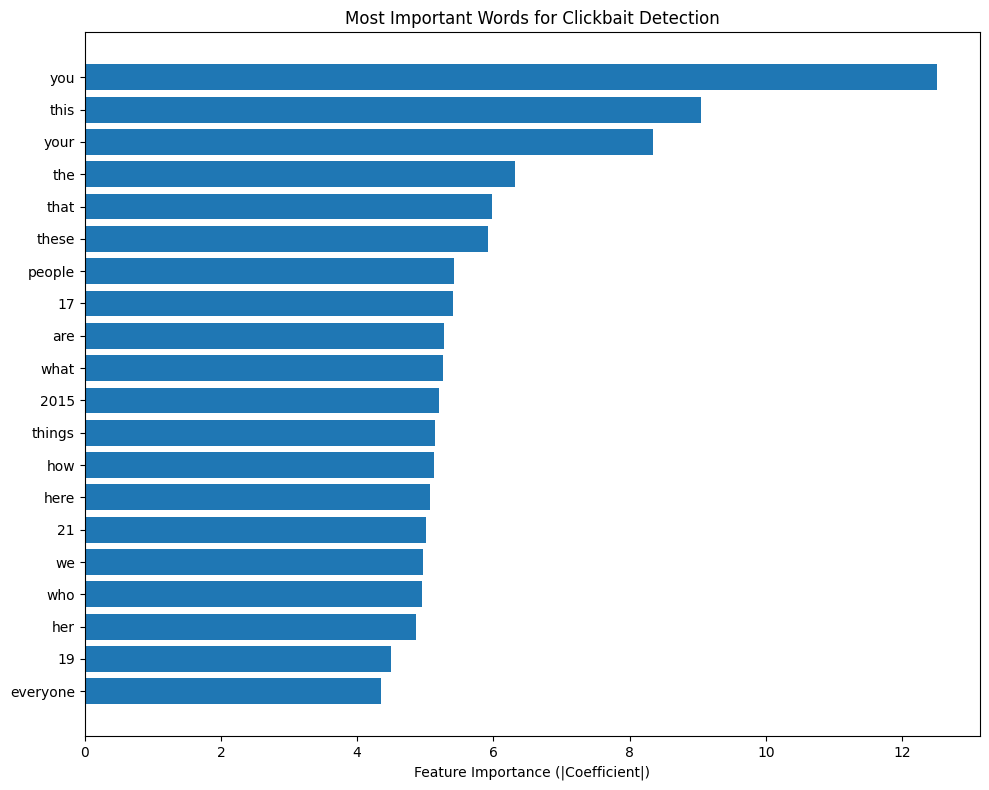

In [40]:
# uzimamo komponente modela
vectorizer = baseline_model.named_steps["tfidf"]
model = baseline_model.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# importance = apsolutna vrednost koeficijenta
importance = np.abs(coefficients)

# top 20 najvažnijih reči
top_idx = np.argsort(importance)[-20:]

top_words = feature_names[top_idx]
top_scores = importance[top_idx]

importance_df = pd.DataFrame({
    "word": top_words,
    "importance": top_scores
}).sort_values("importance")

plt.figure(figsize=(10,8))

plt.barh(importance_df["word"], importance_df["importance"])

plt.xlabel("Feature Importance (|Coefficient|)")
plt.title("Most Important Words for Clickbait Detection")

plt.tight_layout()
plt.show()

Pored analize pozitivnih i negativnih koeficijenata, moguće je analizirati i apsolutne vrednosti koeficijenata kako bi se identifikovale najvažnije karakteristike modela. Apsolutna vrednost koeficijenta pokazuje koliki uticaj određena reč ima na odluku modela, bez obzira na klasu kojoj doprinosi.

Rezultati pokazuju da model najviše koristi reči koje su karakteristične za clickbait stil pisanja, kao i termine koji su tipični za informativne naslove. Ovakva analiza omogućava dodatno razumevanje ponašanja modela i potvrđuje da model koristi relevantne lingvističke obrasce za klasifikaciju naslova.

##  3.5 ROC kriva i AUC

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_prob = baseline_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

auc = roc_auc_score(y_test, y_pred_prob)

print("AUC score:", auc)

AUC score: 0.9949748046875


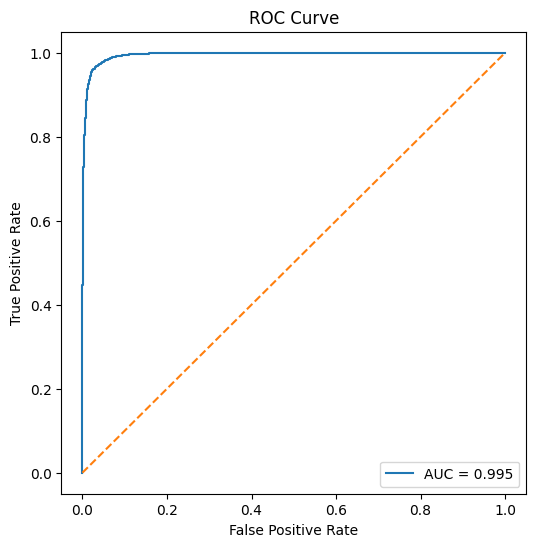

In [42]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

ROC kriva prikazuje odnos između **False Positive Rate (FPR)** i **True Positive Rate (TPR)** za različite vrednosti klasifikacionog praga. Na grafiku se vidi da kriva vrlo brzo raste ka gornjem levom uglu, što znači da model postiže **visoku stopu tačno pozitivnih klasifikacija uz veoma mali broj lažno pozitivnih grešaka**.

Već pri veoma malim vrednostima **FPR** model ostvaruje **TPR blizak 1**, što ukazuje da model uspešno prepoznaje većinu clickbait naslova bez značajnog pogrešnog označavanja ne-clickbait naslova kao clickbait.

Isprekidana dijagonalna linija predstavlja performanse **nasumičnog klasifikatora**. Pošto se ROC kriva modela nalazi značajno iznad te linije, jasno je da model ima **visoku diskriminativnu sposobnost** između dve klase.

Vrednost **AUC (Area Under Curve)** iznosi približno **0.995**, što ukazuje na **izuzetno visok kvalitet modela**. Ova vrednost znači da postoji oko **99.5% verovatnoće da će model dodeliti veću verovatnoću clickbait klasi stvarnom clickbait naslovu nego ne-clickbait naslovu**.

Na osnovu ROC krive i AUC metrike može se zaključiti da bazni model veoma uspešno razlikuje clickbait i ne-clickbait naslove i postiže **veoma visoke performanse klasifikacije**.

## 3.6 Eksperiment sa min_df

Parametar `min_df` u TF-IDF vektorizaciji koristi se za uklanjanje reči koje se pojavljuju u veoma malom broju dokumenata. Takve reči često predstavljaju šum (tipografske greške, retke izraze ili specifične nazive) i mogu povećati dimenzionalnost vokabulara bez značajnog doprinosa modelu.

U ovom eksperimentu testirana je TF-IDF reprezentacija sa parametrom `min_df=5`, što znači da će biti zadržane samo reči koje se pojavljuju u najmanje pet dokumenata u trening skupu.

In [43]:
# TF-IDF sa min_df
vectorizer_min_df = TfidfVectorizer(min_df=5)

X_train_min_df = vectorizer_min_df.fit_transform(X_train)
X_test_min_df = vectorizer_min_df.transform(X_test)

# treniranje modela
model_min_df = LogisticRegression(max_iter=1000)
model_min_df.fit(X_train_min_df, y_train)

# predikcija
y_pred_min_df = model_min_df.predict(X_test_min_df)

print("Classification report:\n")
print(classification_report(y_test, y_pred_min_df))

print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred_min_df))

Classification report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      3200
           1       0.97      0.96      0.97      3200

    accuracy                           0.97      6400
   macro avg       0.97      0.97      0.97      6400
weighted avg       0.97      0.97      0.97      6400

Confusion matrix:

[[3121   79]
 [ 139 3061]]


## 3.7 Eksperiment sa N-gramima

Pored unigram reprezentacije (pojedinačne reči), testiramo i bigram pristup (sekvence od dve reči).
Cilj je da proverimo da li model bolje prepoznaje karakteristične fraze clickbait naslova (npr. “you won’t”, “what happens”, “this is”).

In [44]:
bigram_model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])

In [45]:
bigram_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [46]:
y_pred_bigram = bigram_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report


report_bigram = classification_report(y_test, y_pred_bigram, output_dict=True)
report_df_bigram = pd.DataFrame(report_bigram).transpose()


styled_report_bigram = (
    report_df_bigram.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Bigram Model – Classification Report")
    .set_properties(**{
        'font-size': '18px',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "22px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "15px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "18px"),
                ("text-align", "center")
            ]
        }
    ])
)

styled_report_bigram

,precision,recall,f1-score,support
0,0.9574,0.9753,0.9663,3200
1,0.9748,0.9566,0.9656,3200
accuracy,0.9659,0.9659,0.9659,1
macro avg,0.9661,0.9659,0.9659,6400
weighted avg,0.9661,0.9659,0.9659,6400


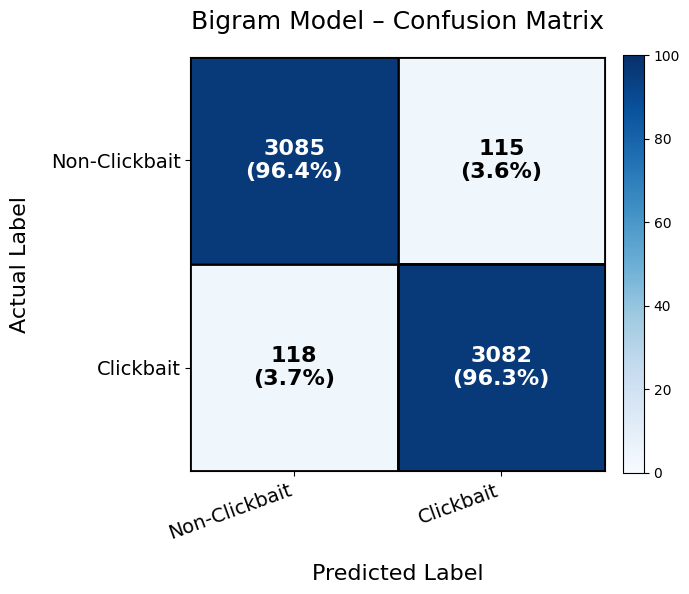

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Kreiramo matricu
cm = confusion_matrix(y_test, y_pred_bigram)

# Računamo procente po redu
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

fig, ax = plt.subplots(figsize=(7, 7))

# JAČI colormap
im = ax.imshow(cm_percent, cmap="Blues", vmin=0, vmax=100)

# Obeležavanje osa
classes = ["Non-Clickbait", "Clickbait"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=14)
ax.set_yticklabels(classes, fontsize=14)

ax.set_xlabel("Predicted Label", fontsize=16, labelpad=15)
ax.set_ylabel("Actual Label", fontsize=16, labelpad=15)

# Rotacija x labela
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# Upis vrednosti unutar kvadrata
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm_percent[i, j] > 50 else "black"
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            color=text_color,
            fontsize=16,
            fontweight="bold"
        )

# Kvadrati jednake veličine
ax.set_aspect("equal")

# Grid linije
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Naslov
plt.title("Bigram Model – Confusion Matrix", fontsize=18, pad=20)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Bigram model ostvaruje ukupnu tačnost od **96.36%**, što je vrlo blizu performansama baseline modela.

F1-score vrednosti su:

- Non-Clickbait: **0.9636**
- Clickbait: **0.9636**

Konfuziona matrica pokazuje da model pravi približno sličan broj grešaka u obe klase:

- 115 non-clickbait naslova pogrešno klasifikovano kao clickbait
- 118 clickbait naslova pogrešno klasifikovano kao non-clickbait

Iako bigram pristup omogućava modelu da prepoznaje fraze (sekvence od dve reči), rezultati pokazuju da u ovom skupu podataka to **ne donosi značajno poboljšanje performansi** u odnosu na jednostavniji unigram model.

#### Poređenje modela

Upoređivanjem rezultata može se zaključiti da:

- **Baseline model ostvaruje blago bolje performanse**.
- Uvođenje bigrama povećava kompleksnost modela, ali ne donosi značajan dobitak u tačnosti.
- Jednostavnija reprezentacija zasnovana na pojedinačnim rečima (unigram) pokazuje se kao dovoljna za ovaj zadatak.

Ovi rezultati sugerišu da je u ovom slučaju **TF-IDF reprezentacija sa unigramima već dovoljno informativna** za razlikovanje clickbait i non-clickbait naslova.

# 4. Uticaj napredne predobrade na performanse modela

## 4.1 Stemming

U cilju ispitivanja uticaja napredne predobrade na performanse modela, primenjen je stemming kao tehnika redukcije reči na korenski oblik. Ova transformacija smanjuje dimenzionalnost vokabulara i potencijalno poboljšava generalizaciju modela.

Rezultati stemming modela biće upoređeni sa baseline modelom zasnovanim na standardnom TF-IDF prikazu bez redukcije reči.

In [49]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text_for_model(text):
    tokens = tokenize_for_eda(text)
    return " ".join([stemmer.stem(t) for t in tokens])

df["headline_stemmed"] = df["headline"].apply(stem_text_for_model)

In [50]:
X_stem = df["headline_stemmed"]

X_train_stem, X_test_stem, y_train, y_test = train_test_split(
    X_stem, df["clickbait"], 
    test_size=0.2, 
    random_state=42,
    stratify=df["clickbait"]
)

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

vectorizer_stem = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer_stem.fit_transform(X_train_stem)
X_test_vec = vectorizer_stem.transform(X_test_stem)

model_stem = LogisticRegression(max_iter=1000)
model_stem.fit(X_train_vec, y_train)

y_pred_stem = model_stem.predict(X_test_vec)

report_dict_stem = classification_report(
    y_test,
    y_pred_stem,
    output_dict=True
)

report_df_stem = pd.DataFrame(report_dict_stem).transpose()

report_df_stem = report_df_stem.loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]

report_df_stem.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

report_df_stem = report_df_stem.round(4)

styled_report_stem = (
    report_df_stem.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Stemming Model – Classification Report")
    .set_properties(**{
        'font-size': '18px',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "22px"),
                   ("font-weight", "bold"),
                   ("text-align", "center"),
                   ("margin-bottom", "15px")]},
        {"selector": "th",
         "props": [("font-size", "18px"),
                   ("text-align", "center")]},
    ])
)

styled_report_stem

,precision,recall,f1-score,support
Non-Clickbait,0.9340,0.9594,0.9465,3200
Clickbait,0.9582,0.9322,0.9450,3200
Accuracy,0.9458,0.9458,0.9458,1
Macro Avg,0.9461,0.9458,0.9458,6400
Weighted Avg,0.9461,0.9458,0.9458,6400


In [52]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Stemming"],
    "Accuracy": [
        report_df.loc["Accuracy", "precision"],
        report_df_stem.loc["Accuracy", "precision"]
    ],
    "F1-Score (Clickbait)": [
        report_df.loc["Clickbait", "f1-score"],
        report_df_stem.loc["Clickbait", "f1-score"]
    ],
    "Macro F1": [
        report_df.loc["Macro Avg", "f1-score"],
        report_df_stem.loc["Macro Avg", "f1-score"]
    ]
})

comparison_df

,Model,Accuracy,F1-Score (Clickbait),Macro F1
0,Baseline,0.9677,0.9673,0.9677
1,Stemming,0.9458,0.9450,0.9458


**Uticaj stemming-a na performanse modela**

Rezultati eksperimenta pokazuju da primena stemming tehnike dovodi do smanjenja performansi modela u odnosu na baseline pristup. Accuracy je opala sa 0.9677 na 0.9458, dok je F1-score za clickbait klasu smanjen sa 0.9673 na 0.9450.

Ovi rezultati sugerišu da agresivna redukcija reči putem stemming-a može dovesti do gubitka semantičkih nijansi, što je posebno izraženo kod kratkih tekstova poput naslova. Budući da svaki token u kratkom tekstu nosi značajnu informativnu vrednost, redukcija morfoloških varijanti može narušiti sposobnost modela da razlikuje klase.

Ovaj eksperiment potvrđuje da napredna predobrada ne mora nužno dovesti do poboljšanja performansi, te da izbor tehnike zavisi od prirode podataka i zadatka klasifikacije.*

## Lemantizacija

Za razliku od stemming-a, lematizacija koristi lingvistička pravila kako bi reči svela na njihov gramatički ispravan osnovni oblik. Očekuje se da lematizacija zadrži više semantičke informacije u odnosu na agresivni stemming pristup.

U nastavku se ispituje uticaj lematizacije na performanse modela i vrši poređenje sa baseline i stemming pristupom.

In [53]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [54]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text_for_model(text):
    tokens = tokenize_for_eda(text)
    return " ".join([lemmatizer.lemmatize(t) for t in tokens])

df["headline_lemmatized"] = df["headline"].apply(lemmatize_text_for_model)

In [55]:
X_lemma = df["headline_lemmatized"]

X_train_lemma, X_test_lemma, y_train, y_test = train_test_split(
    X_lemma,
    df["clickbait"],
    test_size=0.2,
    random_state=42,
    stratify=df["clickbait"]
)

In [56]:
vectorizer_lemma = TfidfVectorizer(stop_words="english")

X_train_vec_lemma = vectorizer_lemma.fit_transform(X_train_lemma)
X_test_vec_lemma = vectorizer_lemma.transform(X_test_lemma)

model_lemma = LogisticRegression(max_iter=1000)
model_lemma.fit(X_train_vec_lemma, y_train)

y_pred_lemma = model_lemma.predict(X_test_vec_lemma)

In [57]:
report_dict_lemma = classification_report(
    y_test,
    y_pred_lemma,
    output_dict=True
)

report_df_lemma = pd.DataFrame(report_dict_lemma).transpose()

report_df_lemma = report_df_lemma.loc[
    ["0", "1", "accuracy", "macro avg", "weighted avg"]
]

report_df_lemma.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

report_df_lemma = report_df_lemma.round(4)

styled_report_lemma = (
    report_df_lemma.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Lemmatization Model – Classification Report")
)

styled_report_lemma

,precision,recall,f1-score,support
Non-Clickbait,0.9379,0.9581,0.9479,3200
Clickbait,0.9572,0.9366,0.9468,3200
Accuracy,0.9473,0.9473,0.9473,1
Macro Avg,0.9476,0.9473,0.9473,6400
Weighted Avg,0.9476,0.9473,0.9473,6400


In [58]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Stemming", "Lemmatization"],
    "Accuracy": [
        report_df.loc["Accuracy", "precision"],
        report_df_stem.loc["Accuracy", "precision"],
        report_df_lemma.loc["Accuracy", "precision"]
    ],
    "F1-Score (Clickbait)": [
        report_df.loc["Clickbait", "f1-score"],
        report_df_stem.loc["Clickbait", "f1-score"],
        report_df_lemma.loc["Clickbait", "f1-score"]
    ],
    "Macro F1": [
        report_df.loc["Macro Avg", "f1-score"],
        report_df_stem.loc["Macro Avg", "f1-score"],
        report_df_lemma.loc["Macro Avg", "f1-score"]
    ]
})

comparison_df

,Model,Accuracy,F1-Score (Clickbait),Macro F1
0,Baseline,0.9677,0.9673,0.9677
1,Stemming,0.9458,0.9450,0.9458
2,Lemmatization,0.9473,0.9468,0.9473


Poređenje pristupa predobrade

Eksperimentalni rezultati pokazuju da ni stemming ni lematizacija nisu doveli do poboljšanja performansi u odnosu na baseline model. Naprotiv, zabeležen je pad Accuracy i F1-score metrike.

Ovi nalazi ukazuju da kod kratkih tekstova, poput naslova, svaka reč nosi značajnu informativnu vrednost, te agresivna redukcija morfoloških oblika može dovesti do gubitka diskriminativne informacije.

Takođe, TF-IDF reprezentacija već implicitno ublažava varijacije u učestalosti termina, čime se smanjuje potreba za dodatnom morfološkom normalizacijom.

Rezultati potvrđuju da izbor tehnike predobrade mora biti prilagođen prirodi podataka i zadatku klasifikacije.

## 5. Zakljucak 

U ovom praktičnom delu rada analiziran je skup podataka koji sadrži naslove vesti označene kao *clickbait* i *non-clickbait*. Cilj analize bio je da se ispita kako kvalitet i karakteristike tekstualnih podataka utiču na performanse modela mašinskog učenja za klasifikaciju tekstova.

Najpre je sprovedena eksplorativna analiza podataka. Analizirana je raspodela klasa, dužina naslova, kao i prisustvo određenih stilskih elemenata kao što su uzvičnici, upitnici, brojevi i reči napisane velikim slovima. Rezultati su pokazali da clickbait naslovi češće koriste emocionalno obojene izraze, interpunkciju i retorička pitanja kako bi privukli pažnju čitalaca, dok su non-clickbait naslovi uglavnom informativniji i neutralniji.

Vizuelizacija reči putem WordCloud analize dodatno je potvrdila razlike u vokabularu između ove dve kategorije. Clickbait naslovi često sadrže izraze koji izazivaju radoznalost ili iznenađenje, dok se u ne-clickbait naslovima češće pojavljuju konkretni pojmovi i informativni termini.

Za modeliranje je korišćen pristup zasnovan na TF-IDF reprezentaciji teksta i logističkoj regresiji kao baznom modelu klasifikacije. Dobijeni rezultati pokazuju vrlo visoku tačnost klasifikacije, što potvrđuju i evaluacione metrike kao što su precision, recall i F1-score. Analiza konfuzione matrice pokazuje da model veoma uspešno razlikuje dve klase uz minimalan broj pogrešnih klasifikacija.

ROC kriva i AUC vrednost bliska 1 dodatno potvrđuju visok kvalitet modela i njegovu sposobnost da pravilno razdvaja clickbait i non-clickbait naslove.

U okviru dodatnog eksperimenta analiziran je uticaj proširenja reprezentacije teksta korišćenjem n-grama (bigram model). Rezultati pokazuju da proširenje na bigrame ne donosi značajno poboljšanje performansi u odnosu na osnovni unigram model, što ukazuje da su pojedinačne reči već dovoljno informativne za detekciju clickbait sadržaja.

Na osnovu dobijenih rezultata može se zaključiti da su lingvističke karakteristike naslova, kao i kvalitet njihove tekstualne reprezentacije, ključni faktori za uspešnu primenu modela mašinskog učenja u zadacima klasifikacije teksta. Ovaj primer pokazuje kako se tehnike predobrade i reprezentacije tekstualnih podataka mogu efikasno primeniti u analizi i detekciji clickbait sadržaja.